In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Define the path to your local file
file_path = os.path.join('..', 'data', 'raw', 'illinois.txt')

# THE INGESTION LOGIC
# 1. 'sep="\t"': The data is separated by tabs, not commas.
# 2. 'comment="#"': Tells Pandas to ignore all the lines starting with #.
# 3. 'header=0': The first non-comment line is the header.
# 4. 'low_memory=False': Prevents warnings on large files.
df_raw = pd.read_csv(file_path, sep='\t', comment='#', header=0, low_memory=False)

# CRITICAL STEP: Remove the "Data Type" row
# The USGS format puts a row like '5s 15s 20d' immediately after the header.
# We must drop it. It will always be at index 0 after loading.
df_raw = df_raw.drop(0)

# Convert 'datetime' to actual objects so we can plot over time
df_raw['datetime'] = pd.to_datetime(df_raw['datetime'])


# Convert the numerical columns to numbers (they were read as text because of the '5s' row)
# We select columns starting from the 4th one (index 3) to the end
cols_to_convert = df_raw.columns[3:]
for col in cols_to_convert:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')


df_raw.drop(columns=['agency_cd', '49313_80155_00003', '49314_00065_00003', 'site_no','49312_80154_00003_cd', '49313_80155_00003_cd', '49314_00065_00003_cd', '49315_00060_00003_cd'], inplace=True)


df = df_raw.loc[:, ['datetime', '49312_80154_00003', '49315_00060_00003']].rename(
    columns={'datetime': 'date',
    '49312_80154_00003': 'ss_mgpl',
    '49315_00060_00003': 'flow_cfs'}).set_index('date')



# Verify
#df.info()

#print(df.isnull().sum()) #to do something about the missing values
#print(len(df))
#print((5164/len(df))*100)

In [2]:
# we have missing data
# our approach now is to establish a relationship between existing ss and flow data
# after proving the relationship via plot (sediment rating curve), we may use it to fill missing data



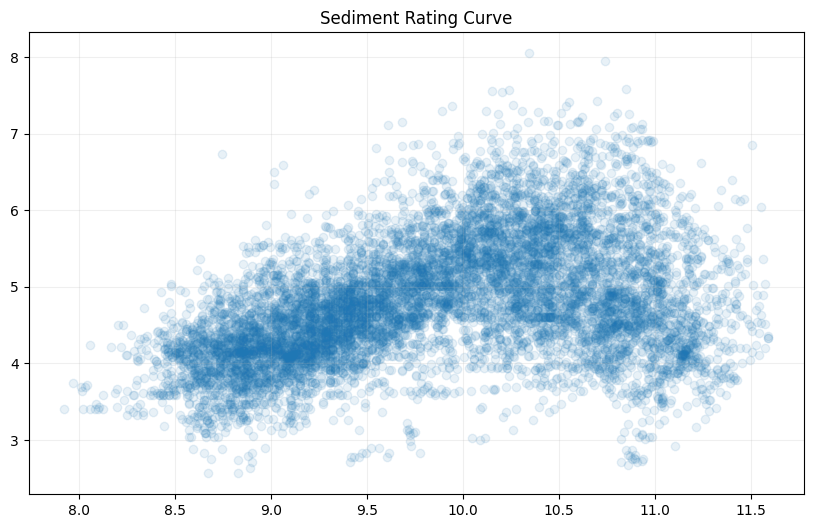

In [3]:
# we chose log scale becasue the flow varies by a lot
# so to view in a single and sufficent canvas


y = np.log(df['ss_mgpl'])
X = np.log(df['flow_cfs'])
plt.figure(figsize=(10,6))

# small alpha to see the overlaps
plt.scatter(X,y, alpha=0.1)


plt.grid(True, which="both", ls="-", alpha=0.2)

plt.title('Sediment Rating Curve')
plt.show() # doesnt take arguements

In [4]:
#noisy plot but we can see the trend
# Log(Sediment)=Slope⋅Log(Flow)+Intercept
# now our first job is to create a clean dataset to train and test the model

dfc = df.dropna().copy() # to make sure dfc is independent of df

from sklearn.model_selection import train_test_split # split the data into education and exam

dftrain, dftest = train_test_split(dfc, test_size = 0.2, random_state = 42)

# dtrain.shape, dtest.shape # to verify

X_train = np.log(dftrain['flow_cfs']).values.reshape(-1,1) # sklearn expects 2D array for features
# .values convert pandas series to numpy array but np.log alr converts to numpy array
# reshape(-1,1) makes it 2D with one column, -1 calculates rows automatically
y_train = np.log(dftrain['ss_mgpl'])
y_test = np.log(dftest['ss_mgpl'])
X_test = np.log(dftest['flow_cfs']).values.reshape(-1,1)

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train) #fit using the trained data

# and predict using the test data

y_pred = model.predict(X_test)


# calculate the mean squared error
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

error = np.exp(rmse)
error # as LOG

np.float64(2.0552388022242893)

In [5]:
fmodel = LinearRegression()
#xfull are the x values that dont contain Nan

# previously we splitted the data into train and test
# now we will use all the existing data to train the model since we are satisfied with the model
#

X_full = np.log(df.dropna()['flow_cfs']).values.reshape(-1, 1)
y_full = np.log(df.dropna()['ss_mgpl'])
fmodel.fit(X_full, y_full)
mask_missing = df['ss_mgpl'].isnull()
X_missing = np.log(df.loc[mask_missing, 'flow_cfs']).values.reshape(-1, 1)

y_missing_pred = fmodel.predict(X_missing)

df.loc[mask_missing, 'ss_mgpl'] = np.exp(y_missing_pred)


df.isnull().sum()  # as LOG
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 14611 entries, 1985-11-18 to 2025-11-18
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ss_mgpl   14611 non-null  float64
 1   flow_cfs  14611 non-null  int64  
dtypes: float64(1), int64(1)
memory usage: 342.4 KB


In [6]:
import sqlite3

db_path = os.path.join('..', 'data', 'processed', 'reservoir.db')

os.makedirs(os.path.dirname(db_path), exist_ok=True) # good practice

# os.makedirs(db_path,...) use this for outpout generating scripts
conn = sqlite3.connect(db_path)

df.to_sql('daily_sediment', conn, if_exists='replace', index=True)

#conn.close()

#c = conn.cursor()

# get sum of sediment per year

# 0.0027 accounts for converting cubic feet to liters, seconds to days, and milligrams to tons

query = """
    SELECT
        SUM(ss_mgpl*flow_cfs*0.0027) AS total_ss_load_1995
    FROM daily_sediment
    WHERE  strftime('%Y', date) = '1995';
"""

results = pd.read_sql_query(query, conn)
# short toness = 2000 lbs
conn.close()
print(f"The total sediment load in 1995 is {results.iloc[0, 0].round(2)} short tonnes.")


The total sediment load in 1995 is 5055217.32 short tonnes.


In [7]:
import matplotlib.ticker as ticker

conn = sqlite3.connect(db_path)
query = """
    SELECT date, flow_cfs, ss_mgpl
    FROM daily_sediment
    ORDER by date
"""

df_viz = pd.read_sql_query(query, conn, parse_dates=['date'])
conn.close()

#bascially what we did in the 1995 sql query but for all years

df_viz['daily_load_tons'] = df_viz['ss_mgpl'] * df_viz['flow_cfs'] * 0.0027

df_viz['cumulative_sediment_tons'] = df_viz['daily_load_tons'].cumsum()



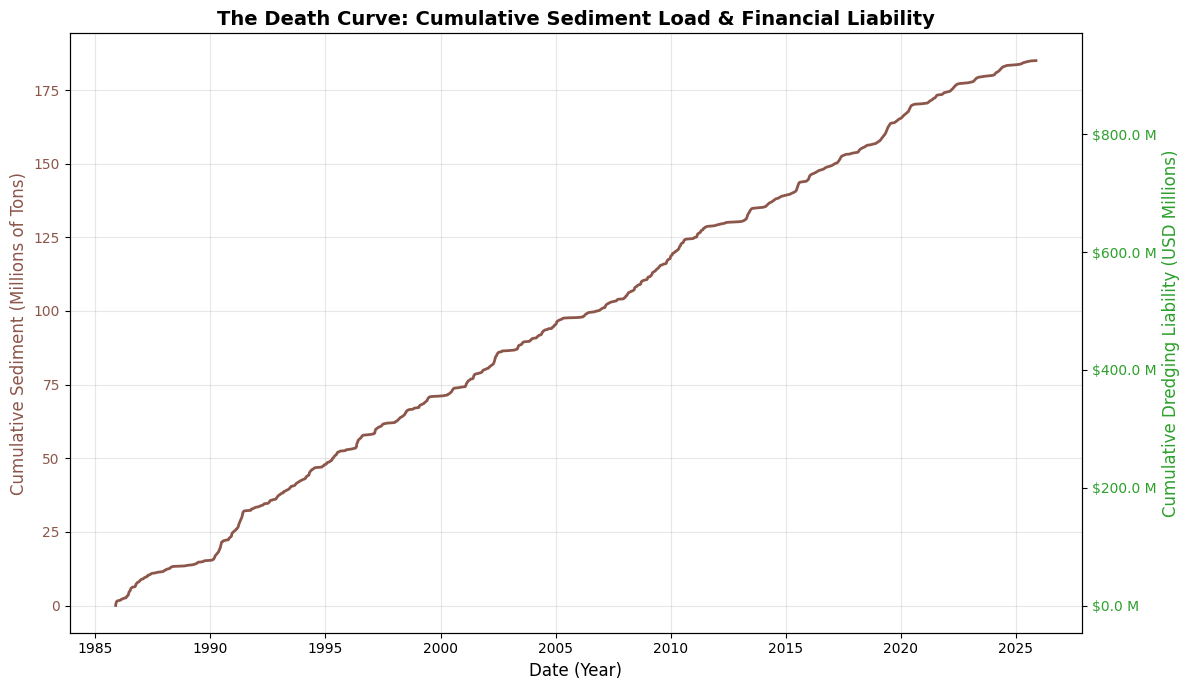

In [8]:
#dual axis visualization

# Setup the canvas
fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot 1: Physical Load (Left Axis)
color_phys = 'tab:brown'
ax1.set_xlabel('Date (Year)', fontsize=12)
ax1.set_ylabel('Cumulative Sediment (Millions of Tons)', color=color_phys, fontsize=12)
ax1.plot(df_viz['date'], df_viz['cumulative_sediment_tons'] / 1_000_000, color=color_phys, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color_phys)
ax1.grid(True, alpha=0.3)

# Plot 2: Financial Liability (Right Axis)
# twinx() creates a second axes that shares the same x-axis
ax2 = ax1.twinx()
color_fin = 'tab:green'
ax2.set_ylabel('Cumulative Dredging Liability (USD Millions)', color=color_fin, fontsize=12)


DREDGING_COST_PER_TON = 5  # $5 per ton
y_min, y_max = ax1.get_ylim()
# Scale the second axis limits by the Cost Factor ($5)
ax2.set_ylim(y_min * DREDGING_COST_PER_TON, y_max * DREDGING_COST_PER_TON)
ax2.tick_params(axis='y', labelcolor=color_fin)

# div by 1_000_000 to convert to millions

# Format the Right Axis as Currency
formatter = ticker.FormatStrFormatter('$%.1f M')
ax2.yaxis.set_major_formatter(formatter)

# Title and Layout
plt.title('The Death Curve: Cumulative Sediment Load & Financial Liability', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()